In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_PATH = "../data/raw/PhiUSIIL_Phishing_URL_Dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 235795
Columns: 56


In [10]:


missing_summary = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

print(missing_summary)

FILENAME                      0
URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMatchScore         0
URLTitle

In [11]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [13]:
[column for column in df.columns if "url" in column.lower()]
df["URL"].head(10).to_list()

['https://www.southbankmosaics.com',
 'https://www.uni-mainz.de',
 'https://www.voicefmradio.co.uk',
 'https://www.sfnmjournal.com',
 'https://www.rewildingargentina.org',
 'https://www.globalreporting.org',
 'https://www.saffronart.com',
 'https://www.nerdscandy.com',
 'https://www.hyderabadonline.in',
 'https://www.aap.org']

In [14]:
[
    column for column in df.columns
    if any(word in column.lower() for word in ["label", "class", "target", "phish"])
]

['label']

In [15]:
categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns

print("Categorical columns:")
for column in categorical_columns:
    print("-", column)

Categorical columns:
- FILENAME
- URL
- Domain
- TLD
- Title


C:\Users\manie\AppData\Local\Temp\ipykernel_15620\2480000713.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [17]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns

print("Number of numerical columns:", len(numerical_columns))

for column in numerical_columns:
    print("-", column)

Number of numerical columns: 51
- URLLength
- DomainLength
- IsDomainIP
- URLSimilarityIndex
- CharContinuationRate
- TLDLegitimateProb
- URLCharProb
- TLDLength
- NoOfSubDomain
- HasObfuscation
- NoOfObfuscatedChar
- ObfuscationRatio
- NoOfLettersInURL
- LetterRatioInURL
- NoOfDegitsInURL
- DegitRatioInURL
- NoOfEqualsInURL
- NoOfQMarkInURL
- NoOfAmpersandInURL
- NoOfOtherSpecialCharsInURL
- SpacialCharRatioInURL
- IsHTTPS
- LineOfCode
- LargestLineLength
- HasTitle
- DomainTitleMatchScore
- URLTitleMatchScore
- HasFavicon
- Robots
- IsResponsive
- NoOfURLRedirect
- NoOfSelfRedirect
- HasDescription
- NoOfPopup
- NoOfiFrame
- HasExternalFormSubmit
- HasSocialNet
- HasSubmitButton
- HasHiddenFields
- HasPasswordField
- Bank
- Pay
- Crypto
- HasCopyrightInfo
- NoOfImage
- NoOfCSS
- NoOfJS
- NoOfSelfRef
- NoOfEmptyRef
- NoOfExternalRef
- label


In [18]:
df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


In [22]:
TARGET_COLUMN = "label"
print(df[TARGET_COLUMN].value_counts())
print(df[TARGET_COLUMN].value_counts(normalize=True) * 100)

label
1    134850
0    100945
Name: count, dtype: int64
label
1    57.189508
0    42.810492
Name: proportion, dtype: float64


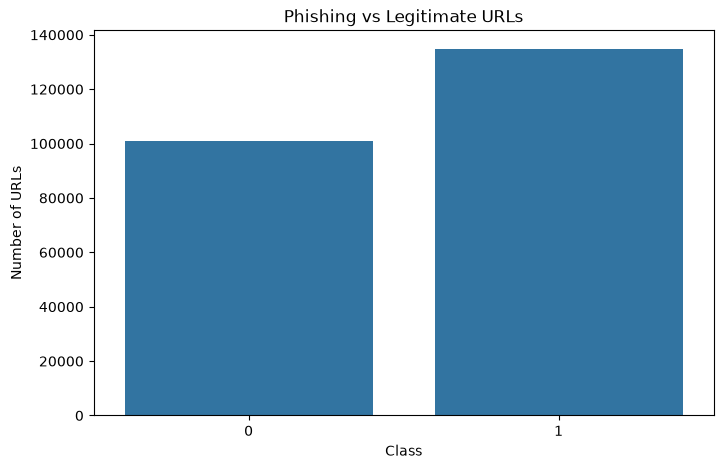

In [23]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x=TARGET_COLUMN)

plt.title("Phishing vs Legitimate URLs")
plt.xlabel("Class")
plt.ylabel("Number of URLs")

plt.show()

In [24]:
url_column = "URL"

print("Total URLs:", len(df))
print("Unique URLs:", df[url_column].nunique())
print("Duplicate URLs:", df[url_column].duplicated().sum())

Total URLs: 235795
Unique URLs: 235370
Duplicate URLs: 425


In [25]:
duplicate_url_groups = (
    df.groupby(url_column)[TARGET_COLUMN]
      .nunique()
)

print(
    "URLs appearing with multiple target labels:",
    (duplicate_url_groups > 1).sum()
)

URLs appearing with multiple target labels: 0


In [26]:
print("=" * 60)
print("DATASET PROFILE")
print("=" * 60)

print(f"Rows              : {df.shape[0]:,}")
print(f"Columns           : {df.shape[1]}")
print(f"Missing values    : {df.isnull().sum().sum():,}")
print(f"Duplicate rows    : {df.duplicated().sum():,}")
print(f"Unique URLs       : {df[url_column].nunique():,}")
print(f"Memory usage      : {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

print("\nTarget distribution:")
print(df[TARGET_COLUMN].value_counts())

DATASET PROFILE
Rows              : 235,795
Columns           : 56
Missing values    : 0
Duplicate rows    : 0
Unique URLs       : 235,370
Memory usage      : 166.17 MB

Target distribution:
label
1    134850
0    100945
Name: count, dtype: int64
